In [ ]:
# TP2.ipynb -  GHRoxo

import os
import sys
import importlib
import warnings

from google.colab import drive

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/ACA_P2'

os.chdir(project_path)

if project_path not in sys.path:
    sys.path.append(project_path)

print(f"Diretório atualizado: {os.getcwd()}")

!pip install -q kagglehub==1.0.0


import torch
import torch.nn as nn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split

from torchvision import transforms

from torch.utils.data import DataLoader

from torchvision.utils import save_image

import config
import models
import pipelines

importlib.reload(config)
importlib.reload(models)
importlib.reload(pipelines)

from config import ProjectConfig as cfg

from models import (
    ButterflyDataset,
    AugmentedButterflyDataset,
    HybridButterflyDataset,
    BaselineCNN,
    CGANGenerator,
    CGANDiscriminator,
    ConvVAE
)

from pipelines import (
    train_classifier,
    train_conditional_gan,
    train_vae_conditional,
    init_dcgan_weights
)

print("Módulos carregados com sucesso!")

torch.manual_seed(cfg.SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

warnings.filterwarnings("ignore", category=UserWarning)

os.environ["PYTHONWARNINGS"] = "ignore"

Mounted at /content/drive
Diretório atualizado: /content/drive/.shortcut-targets-by-id/16lInX22HTlm2JkT6LlbIhtntwPVGlazi/ACA_P2
Módulos carregados com sucesso!


In [ ]:
print("Autenticando no Kaggle...")

try:
    kagglehub.login()
except Exception as e:
    print("Erro ao abrir login automático.")

print("Baixando dados...")

path = kagglehub.competition_download('aca-tp-2')

img_dir = os.path.join(path, 'train')

df_full = pd.read_csv(
    os.path.join(path, 'train.csv')
)

print(f"Dataset carregado de: {path}")

Autenticando no Kaggle...


Baixando dados...


100%|██████████| 158M/158M [00:01<00:00, 95.7MB/s]

Extracting files...


Dataset carregado de: /root/.cache/kagglehub/competitions/aca-tp-2


In [ ]:
# 15% reservado exclusivamente para teste final
df_temp, df_test = train_test_split(
    df_full,
    test_size=0.15,
    stratify=df_full['label'],
    random_state=cfg.SEED
)

# 70% treino / 15% validação
df_train, df_val = train_test_split(
    df_temp,
    test_size=0.1765,
    stratify=df_temp['label'],
    random_state=cfg.SEED
)

print("=== Divisão de Dados Concluída ===")

print(f"Treino:    {len(df_train)} imagens (~70%)")
print(f"Validação: {len(df_val)} imagens (~15%)")
print(f"Teste:     {len(df_test)} imagens (~15%)")

train_transform = transforms.Compose([

    transforms.Resize(
        (cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ToTensor()
])

val_transform = transforms.Compose([

    transforms.Resize(
        (cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
    ),

    transforms.ToTensor()
])

# GAN usa normalização simétrica [-1, 1]
gan_transform = transforms.Compose([

    transforms.Resize(
        (cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5] * 3,
        [0.5] * 3
    )
])

train_dataset = ButterflyDataset(
    df=df_train,
    img_dir=img_dir,
    transform=train_transform
)

val_dataset = ButterflyDataset(
    df=df_val,
    img_dir=img_dir,
    transform=val_transform,
    class_to_idx=train_dataset.class_to_idx
)

test_dataset = ButterflyDataset(
    df=df_test,
    img_dir=img_dir,
    transform=val_transform,
    class_to_idx=train_dataset.class_to_idx
)

usar_pin_memory = cfg.DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=usar_pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=usar_pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=usar_pin_memory
)

print("\nDataLoaders criados com sucesso!")

=== Divisão de Dados Concluída ===
Treino:    3639 imagens (~70%)
Validação: 780 imagens (~15%)
Teste:     780 imagens (~15%)

DataLoaders criados com sucesso!


In [ ]:
print("=== BASELINE CNN ===")

model_baseline = BaselineCNN(
    num_classes=cfg.NUM_CLASSES
).to(cfg.DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_baseline.parameters(),
    lr=cfg.CNN_LR
)

model_baseline, baseline_history, best_val_acc, baseline_test_acc = train_classifier(
    model_baseline,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    cfg
)

print("\n=== RESULTADO BASELINE ===")

print(f"Melhor Val Acc: {best_val_acc:.4f}")

print(f"Test Acc: {baseline_test_acc:.4f}")

=== BASELINE CNN ===

[INFO] Iniciando treinamento da CNN...

Epoch [1/120] | Train Loss: 4.2050 | Train Acc: 3.05% | Val Loss: 3.8273 | Val Acc: 6.92%
Epoch [2/120] | Train Loss: 3.7859 | Train Acc: 7.09% | Val Loss: 3.6417 | Val Acc: 6.79%
Epoch [3/120] | Train Loss: 3.5774 | Train Acc: 8.52% | Val Loss: 3.4586 | Val Acc: 9.74%
Epoch [4/120] | Train Loss: 3.4367 | Train Acc: 9.29% | Val Loss: 3.4493 | Val Acc: 10.38%
Epoch [5/120] | Train Loss: 3.3224 | Train Acc: 12.23% | Val Loss: 3.2865 | Val Acc: 11.28%
Epoch [6/120] | Train Loss: 3.2347 | Train Acc: 12.50% | Val Loss: 2.9632 | Val Acc: 18.33%
Epoch [7/120] | Train Loss: 3.1731 | Train Acc: 13.96% | Val Loss: 3.1408 | Val Acc: 15.00%
Epoch [8/120] | Train Loss: 3.1549 | Train Acc: 13.82% | Val Loss: 3.0272 | Val Acc: 15.38%
Epoch [9/120] | Train Loss: 3.0725 | Train Acc: 16.68% | Val Loss: 2.9301 | Val Acc: 19.87%
Epoch [10/120] | Train Loss: 2.9936 | Train Acc: 17.50% | Val Loss: 2.8028 | Val Acc: 21.67%
Epoch [11/120] | Train L

In [ ]:
print("=== TREINANDO cGAN ===")

train_dataset_gan = ButterflyDataset(
    df=df_train,
    img_dir=img_dir,
    transform=gan_transform,
    class_to_idx=train_dataset.class_to_idx
)

train_loader_gan = DataLoader(
    train_dataset_gan,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=usar_pin_memory
)

generator = CGANGenerator(
    latent_dim=cfg.GAN_LATENT_DIM,
    num_classes=cfg.NUM_CLASSES
).to(cfg.DEVICE)

discriminator = CGANDiscriminator(
    num_classes=cfg.NUM_CLASSES
).to(cfg.DEVICE)

generator.apply(init_dcgan_weights)

discriminator.apply(init_dcgan_weights)

opt_g = torch.optim.Adam(
    generator.parameters(),
    lr=cfg.GAN_LR,
    betas=(0.0, 0.9)
)

opt_d = torch.optim.Adam(
    discriminator.parameters(),
    lr=cfg.GAN_LR,
    betas=(0.0, 0.9)
)

gan_train_history = train_conditional_gan(
    generator,
    discriminator,
    train_loader_gan,
    opt_g,
    opt_d,
    cfg
)

torch.save(
    generator.state_dict(),
    "best_generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "best_discriminator.pth"
)

print("\ncGAN treinada com sucesso!")

=== TREINANDO cGAN ===

[INFO] Iniciando treinamento da cGAN...



GAN Epoch 1:   0%|          | 0/114 [00:00<?, ?it/s]

GAN Epoch [1/80] | D Loss: 0.9715 | G Loss: 0.9038


GAN Epoch 2:   0%|          | 0/114 [00:00<?, ?it/s]

GAN Epoch [2/80] | D Loss: 1.5446 | G Loss: 0.7083


...

GAN Epoch [78/80] | D Loss: 1.5319 | G Loss: 0.5023


GAN Epoch 79:   0%|          | 0/114 [00:00<?, ?it/s]

GAN Epoch [79/80] | D Loss: 1.5303 | G Loss: 0.5224


GAN Epoch 80:   0%|          | 0/114 [00:00<?, ?it/s]

GAN Epoch [80/80] | D Loss: 1.5627 | G Loss: 0.5124

cGAN treinada com sucesso!


In [ ]:
print("=== GERANDO IMAGENS cGAN ===")

cgan_img_dir = "/content/cgan_augmented_images"

os.makedirs(
    cgan_img_dir,
    exist_ok=True
)


idx_to_class = {
    v: k
    for k, v in train_dataset.class_to_idx.items()
}

synthetic_records_gan = []

generator.eval()


with torch.no_grad():

    # Percorre todas as classes do dataset
    for class_idx in range(cfg.NUM_CLASSES):

        class_name = idx_to_class[class_idx]

        z = torch.randn(
            cfg.GAN_SAMPLE_PER_CLASS,
            cfg.GAN_LATENT_DIM,
            device=cfg.DEVICE
        )

        labels = torch.full(
            (cfg.GAN_SAMPLE_PER_CLASS,),
            class_idx,
            dtype=torch.long,
            device=cfg.DEVICE
        )

        fake_images = generator(
            z,
            labels
        )

        # A GAN produz saída em [-1, 1]
        # Convertendo para [0, 1]
        fake_images = (fake_images + 1) / 2.0

        fake_images = torch.clamp(
            fake_images,
            0.0,
            1.0
        )

        for i in range(cfg.GAN_SAMPLE_PER_CLASS):

            filename = f"cgan_{class_name}_{i}.jpg"

            save_image(
                fake_images[i].cpu(),
                os.path.join(cgan_img_dir, filename)
            )

            synthetic_records_gan.append({
                'filename': filename,
                'label': class_name,
                'is_synthetic': 1
            })

print(
    f"\n[OK] {len(synthetic_records_gan)} imagens cGAN geradas com sucesso!"
)

=== GERANDO IMAGENS cGAN ===

[OK] 1125 imagens cGAN geradas com sucesso!


In [ ]:
print("=== RETREINO CNN + cGAN ===")

df_synth_gan = pd.DataFrame(
    synthetic_records_gan
)

# Usa apenas 30%
df_synth_gan = df_synth_gan.sample(
    frac=0.3,
    random_state=cfg.SEED
)

# Junta reais + sintéticos
df_train_gan = pd.concat([
    df_train.assign(is_synthetic=0),
    df_synth_gan
], ignore_index=True)

aug_train_dataset_gan = AugmentedButterflyDataset(
    df_train_gan,
    img_dir,
    cgan_img_dir,
    train_transform,
    train_dataset.class_to_idx
)

aug_train_loader_gan = DataLoader(
    aug_train_dataset_gan,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=usar_pin_memory
)

model_augmented_gan = BaselineCNN(
    num_classes=cfg.NUM_CLASSES
).to(cfg.DEVICE)

optimizer_gan = torch.optim.Adam(
    model_augmented_gan.parameters(),
    lr=cfg.CNN_LR
)

model_augmented_gan, gan_history, best_aug_val_acc, gan_test_acc = train_classifier(
    model_augmented_gan,
    aug_train_loader_gan,
    val_loader,
    test_loader,
    optimizer_gan,
    criterion,
    cfg
)

print("\n=== RESULTADO CNN + cGAN ===")
print(f"Melhor Val Acc: {best_aug_val_acc:.4f}")
print(f"Test Acc: {gan_test_acc:.4f}")

=== RETREINO CNN + cGAN ===

[INFO] Iniciando treinamento da CNN...

Epoch [1/120] | Train Loss: 4.1835 | Train Acc: 2.97% | Val Loss: 3.7672 | Val Acc: 6.15%
Epoch [2/120] | Train Loss: 3.7839 | Train Acc: 5.93% | Val Loss: 3.6577 | Val Acc: 7.44%
Epoch [3/120] | Train Loss: 3.5595 | Train Acc: 8.73% | Val Loss: 3.3428 | Val Acc: 12.18%
Epoch [4/120] | Train Loss: 3.4088 | Train Acc: 10.06% | Val Loss: 3.2266 | Val Acc: 12.44%
Epoch [5/120] | Train Loss: 3.3008 | Train Acc: 12.04% | Val Loss: 3.0724 | Val Acc: 16.41%
Epoch [6/120] | Train Loss: 3.2757 | Train Acc: 11.94% | Val Loss: 3.0825 | Val Acc: 16.15%
Epoch [7/120] | Train Loss: 3.1730 | Train Acc: 14.38% | Val Loss: 2.8630 | Val Acc: 19.74%
Epoch [8/120] | Train Loss: 3.1476 | Train Acc: 14.46% | Val Loss: 3.2815 | Val Acc: 15.13%
Epoch [9/120] | Train Loss: 3.1089 | Train Acc: 15.26% | Val Loss: 2.8331 | Val Acc: 22.05%
Epoch [10/120] | Train Loss: 3.0281 | Train Acc: 17.35% | Val Loss: 2.9379 | Val Acc: 20.64%
Epoch [11/120] 

In [ ]:
import warnings
import os

# desabilita warnings gerais
warnings.filterwarnings("ignore")

# reduz logs do pytorch
os.environ["PYTHONWARNINGS"] = "ignore"

print("=== TREINANDO C-VAE ===")

vae_model = ConvVAE(
    latent_dim=cfg.VAE_LATENT_DIM,
    num_classes=cfg.NUM_CLASSES
).to(cfg.DEVICE)

vae_optimizer = torch.optim.AdamW(
    vae_model.parameters(),
    lr=cfg.VAE_LR,
    weight_decay=1e-5
)

vae_history, vae_test_loss = train_vae_conditional(
    vae_model,
    train_loader,
    val_loader,
    test_loader,
    vae_optimizer,
    cfg
)

print("\n=== RESULTADO VAE ===")

print(f"Test Loss: {vae_test_loss:.4f}")

=== TREINANDO C-VAE ===

[INFO] Iniciando treinamento do C-VAE...



VAE Epoch 1:   0%|          | 0/114 [00:00<?, ?it/s]

VAE Epoch [1/120] | Beta: 0.033 | Train Loss: 7578.0686 | Val Loss: 7402.5185


VAE Epoch 2:   0%|          | 0/114 [00:00<?, ?it/s]

VAE Epoch [2/120] | Beta: 0.067 | Train Loss: 6797.1493 | Val Loss: 7236.2155


...

VAE Epoch [26/120] | Beta: 0.867 | Train Loss: 6490.1041 | Val Loss: 7043.5250


VAE Epoch 27:   0%|          | 0/114 [00:00<?, ?it/s]

VAE Epoch [27/120] | Beta: 0.900 | Train Loss: 6508.3285 | Val Loss: 7037.5560


VAE Epoch 28:   0%|          | 0/114 [00:00<?, ?it/s]

VAE Epoch [28/120] | Beta: 0.933 | Train Loss: 6509.9347 | Val Loss: 7040.9392

[INFO] Early Stopping no VAE!


[INFO] Carregando melhor modelo do VAE...

[TEST VAE] Loss: 7113.3922

=== RESULTADO VAE ===
Test Loss: 7113.3922


In [ ]:
print("=== GERANDO IMAGENS VAE ===")

vae_img_dir = "/content/vae_augmented_images"

os.makedirs(
    vae_img_dir,
    exist_ok=True
)

synthetic_records_vae = []
vae_model.eval()

with torch.no_grad():

    # Percorre todas as espécies/classes
    for class_idx in range(cfg.NUM_CLASSES):

        class_name = idx_to_class[class_idx]

        z = torch.randn(
            cfg.GAN_SAMPLE_PER_CLASS,
            cfg.VAE_LATENT_DIM,
            device=cfg.DEVICE
        )

        labels = torch.full(
            (cfg.GAN_SAMPLE_PER_CLASS,),
            class_idx,
            dtype=torch.long,
            device=cfg.DEVICE
        )

        fake_images = vae_model.decode(
            z,
            labels
        )

        # O decoder usa Sigmoid -> saída naturalmente em [0, 1]
        # Mesmo assim, aplicamos clamp por segurança numérica
        fake_images = torch.clamp(
            fake_images,
            0.0,
            1.0
        )

        for i in range(cfg.GAN_SAMPLE_PER_CLASS):

            filename = f"vae_{class_name}_{i}.jpg"

            save_image(
                fake_images[i].cpu(),
                os.path.join(vae_img_dir, filename)
            )

            synthetic_records_vae.append({
                'filename': filename,
                'label': class_name,
                'is_synthetic': 1
            })

print(
    f"\n[OK] {len(synthetic_records_vae)} imagens VAE geradas com sucesso!"
)

=== GERANDO IMAGENS VAE ===

[OK] 1125 imagens VAE geradas com sucesso!


In [ ]:
print("=== RETREINO CNN + VAE ===")

df_synth_vae = pd.DataFrame(
    synthetic_records_vae
)

df_synth_vae = df_synth_vae.sample(
    frac=0.3,
    random_state=cfg.SEED
)

df_train_vae = pd.concat([
    df_train.assign(is_synthetic=0),
    df_synth_vae
], ignore_index=True)

aug_train_dataset_vae = AugmentedButterflyDataset(
    df_train_vae,
    img_dir,
    vae_img_dir,
    train_transform,
    train_dataset.class_to_idx
)

aug_train_loader_vae = DataLoader(
    aug_train_dataset_vae,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=usar_pin_memory
)

model_augmented_vae = BaselineCNN(
    num_classes=cfg.NUM_CLASSES
).to(cfg.DEVICE)

optimizer_vae = torch.optim.Adam(
    model_augmented_vae.parameters(),
    lr=cfg.CNN_LR
)

model_augmented_vae, vae_history_cnn, best_vae_val_acc, vae_cnn_test_acc = train_classifier(
    model_augmented_vae,
    aug_train_loader_vae,
    val_loader,
    test_loader,
    optimizer_vae,
    criterion,
    cfg
)

print("\n=== RESULTADO CNN + VAE ===")
print(f"Melhor Val Acc: {best_vae_val_acc:.4f}")
print(f"Test Acc: {vae_cnn_test_acc:.4f}")

=== RETREINO CNN + VAE ===

[INFO] Iniciando treinamento da CNN...



Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^ 

Epoch [1/120] | Train Loss: 4.2418 | Train Acc: 2.64% | Val Loss: 4.0418 | Val Acc: 3.72%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():    assert self._parent_pid == os.getpid(), 'can only test a child process'

                ^ ^^^ ^^^^^^^^^^^^^^
^  Fil

Epoch [2/120] | Train Loss: 3.9908 | Train Acc: 4.17% | Val Loss: 3.9012 | Val Acc: 5.90%


...

Epoch [48/120] | Train Loss: 2.1338 | Train Acc: 38.75% | Val Loss: 1.6313 | Val Acc: 54.10%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Exception ignored in: self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

    if w.is_alive():
 Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^^ ^^ ^ ^^  ^  
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^^ ^ ^ ^^ ^ ^ 
  File "/usr/lib

Epoch [49/120] | Train Loss: 2.1115 | Train Acc: 39.15% | Val Loss: 1.6242 | Val Acc: 50.51%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:     if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>

 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
  ^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():
^  ^^ ^ ^ ^ ^^ 
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^  ^^ ^
  File "/usr/lib

Epoch [50/120] | Train Loss: 2.0912 | Train Acc: 39.70% | Val Loss: 1.5984 | Val Acc: 51.79%
Epoch [51/120] | Train Loss: 2.0985 | Train Acc: 39.80% | Val Loss: 1.5993 | Val Acc: 50.90%
Epoch [52/120] | Train Loss: 2.0168 | Train Acc: 41.89% | Val Loss: 1.4785 | Val Acc: 60.00%
Epoch [53/120] | Train Loss: 2.0827 | Train Acc: 41.04% | Val Loss: 1.4786 | Val Acc: 58.08%
Epoch [54/120] | Train Loss: 2.0132 | Train Acc: 42.24% | Val Loss: 1.5645 | Val Acc: 54.62%
Epoch [55/120] | Train Loss: 2.0287 | Train Acc: 41.97% | Val Loss: 1.5680 | Val Acc: 53.59%
Epoch [56/120] | Train Loss: 1.9910 | Train Acc: 42.24% | Val Loss: 1.4187 | Val Acc: 60.00%
Epoch [57/120] | Train Loss: 1.9979 | Train Acc: 42.02% | Val Loss: 1.6369 | Val Acc: 52.05%
Epoch [58/120] | Train Loss: 1.9786 | Train Acc: 43.50% | Val Loss: 1.4314 | Val Acc: 58.97%
Epoch [59/120] | Train Loss: 1.9749 | Train Acc: 43.83% | Val Loss: 1.4693 | Val Acc: 58.97%
Epoch [60/120] | Train Loss: 1.9785 | Train Acc: 43.15% | Val Loss: 1.

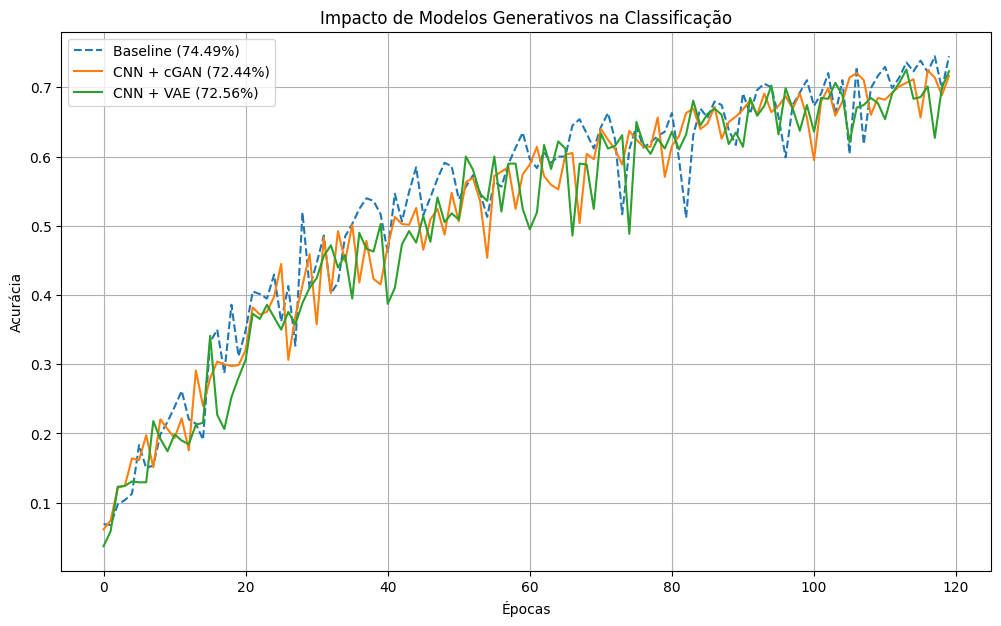

In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(
    baseline_history['val_acc'],
    # (CNN treinada puramente com dados reais)
    label=f"Baseline ({best_val_acc*100:.2f}%)",
    linestyle='--'
)

plt.plot(
    gan_history['val_acc'],
    # (CNN treinada com dados reais + ajuda do C-GAN)
    label=f"CNN + cGAN ({best_aug_val_acc*100:.2f}%)"
)

plt.plot(
    vae_history_cnn['val_acc'],
    # (CNN treinada com dados reais + ajuda do C-VAE)
    label=f"CNN + VAE ({best_vae_val_acc*100:.2f}%)"
)

plt.title(
    'Impacto de Modelos Generativos na Classificação'
)

plt.xlabel('Épocas')

plt.ylabel('Acurácia')

plt.legend()

plt.grid(True)

plt.savefig(
    'comparativo_algoritmos_final.png'
)

plt.show()

In [ ]:
print("=== RETREINO CNN + HÍBRIDO (cGAN & VAE) ===")

df_synth_gan_15 = pd.DataFrame(
    synthetic_records_gan
).sample(
    frac=0.15,
    random_state=cfg.SEED
)

df_synth_vae_15 = pd.DataFrame(
    synthetic_records_vae
).sample(
    frac=0.15,
    random_state=cfg.SEED
)

df_synth_gan_15['folder_type'] = 'cgan'

df_synth_vae_15['folder_type'] = 'vae'

df_train_base = df_train.assign(
    is_synthetic=0,
    folder_type='real'
)

df_synth_gan_15['is_synthetic'] = 1
df_synth_vae_15['is_synthetic'] = 1

df_train_hybrid = pd.concat([
    df_train_base,
    df_synth_gan_15,
    df_synth_vae_15
], ignore_index=True)

hybrid_train_dataset = HybridButterflyDataset(
    df=df_train_hybrid,
    img_dir=img_dir,
    cgan_img_dir=cgan_img_dir,
    vae_img_dir=vae_img_dir,
    transform=train_transform,
    class_to_idx=train_dataset.class_to_idx
)

hybrid_train_loader = DataLoader(
    hybrid_train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=usar_pin_memory
)

model_hybrid = BaselineCNN(
    num_classes=cfg.NUM_CLASSES
).to(cfg.DEVICE)

optimizer_hybrid = torch.optim.Adam(
    model_hybrid.parameters(),
    lr=cfg.CNN_LR
)

model_hybrid, hybrid_history, best_hybrid_val_acc, hybrid_test_acc = train_classifier(
    model_hybrid,
    hybrid_train_loader,
    val_loader,
    test_loader,
    optimizer_hybrid,
    criterion,
    cfg
)

print("\n=== RESULTADO HÍBRIDO ===")
print(f"Melhor Val Acc: {best_hybrid_val_acc:.4f}")
print(f"Test Acc: {hybrid_test_acc:.4f}")

=== RETREINO CNN + HÍBRIDO (cGAN & VAE) ===

[INFO] Iniciando treinamento da CNN...

Epoch [1/120] | Train Loss: 4.2180 | Train Acc: 2.99% | Val Loss: 4.3129 | Val Acc: 2.69%
Epoch [2/120] | Train Loss: 3.9107 | Train Acc: 4.60% | Val Loss: 3.7341 | Val Acc: 5.77%
Epoch [3/120] | Train Loss: 3.7500 | Train Acc: 7.19% | Val Loss: 3.5906 | Val Acc: 10.13%
Epoch [4/120] | Train Loss: 3.5954 | Train Acc: 8.37% | Val Loss: 3.3522 | Val Acc: 11.92%
Epoch [5/120] | Train Loss: 3.4855 | Train Acc: 9.66% | Val Loss: 3.1897 | Val Acc: 16.28%
Epoch [6/120] | Train Loss: 3.3946 | Train Acc: 11.16% | Val Loss: 3.1641 | Val Acc: 12.44%
Epoch [7/120] | Train Loss: 3.3144 | Train Acc: 12.09% | Val Loss: 3.0385 | Val Acc: 16.92%
Epoch [8/120] | Train Loss: 3.2546 | Train Acc: 13.43% | Val Loss: 3.0980 | Val Acc: 15.13%
Epoch [9/120] | Train Loss: 3.2222 | Train Acc: 14.13% | Val Loss: 2.9298 | Val Acc: 16.28%
Epoch [10/120] | Train Loss: 3.1766 | Train Acc: 14.84% | Val Loss: 3.0795 | Val Acc: 17.31%
E

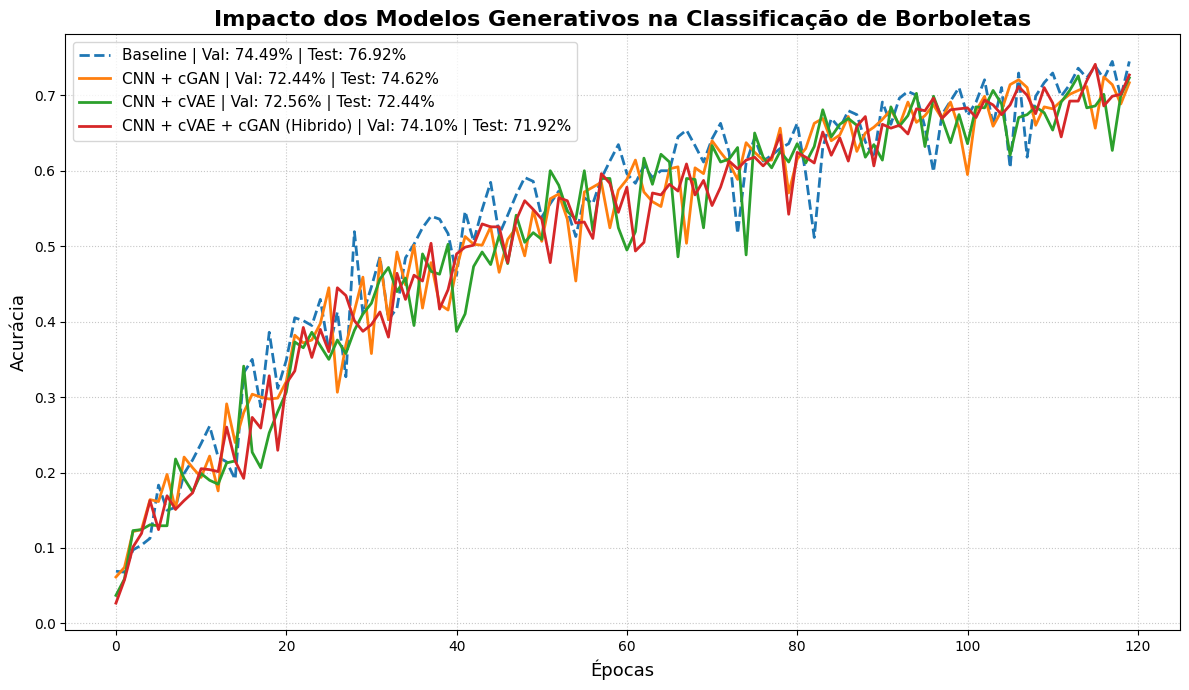


[OK] Gráfico comparativo salvo como 'comparativo_algoritmos_final2.png'


In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(
    baseline_history['val_acc'],
    label=(
        f"Baseline | "
        f"Val: {best_val_acc*100:.2f}% | "
        f"Test: {baseline_test_acc*100:.2f}%"
    ),
    linestyle='--',
    linewidth=2
)

plt.plot(
    gan_history['val_acc'],
    label=(
        f"CNN + cGAN | "
        f"Val: {best_aug_val_acc*100:.2f}% | "
        f"Test: {gan_test_acc*100:.2f}%"
    ),
    linewidth=2
)

plt.plot(
    vae_history_cnn['val_acc'],
    label=(
        f"CNN + cVAE | "
        f"Val: {best_vae_val_acc*100:.2f}% | "
        f"Test: {vae_cnn_test_acc*100:.2f}%"
    ),
    linewidth=2
)

plt.plot(
    hybrid_history['val_acc'],
    label=(
        f"CNN + cVAE + cGAN (Hibrido) | "
        f"Val: {best_hybrid_val_acc*100:.2f}% | "
        f"Test: {hybrid_test_acc*100:.2f}%"
    ),
    linewidth=2
)

plt.title(
    'Impacto dos Modelos Generativos na Classificação de Borboletas',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Épocas',
    fontsize=13
)

plt.ylabel(
    'Acurácia',
    fontsize=13
)

plt.legend(
    fontsize=11
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    'comparativo_algoritmos_final2.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\n[OK] Gráfico comparativo salvo como 'comparativo_algoritmos_final2.png'")

In [ ]:
# IMPLEMENTAÇÃO DE MÉTRICAS: FID E SSIM

print("Instalando dependencias de metricas...")
!pip install -q torchmetrics[image]==1.4.0.post0

import torch
from torchmetrics.image import FrechetInceptionDistance
from torchmetrics.functional.image import structural_similarity_index_measure
from tqdm.auto import tqdm

# CÁLCULO DO FID (Fréchet Inception Distance)
def calcular_fid_experimento(real_loader, generator_model, vae_model, device, max_imgs=1000):
    """
    Calcula o FID comparando o Dataset Real contra a cGAN e contra o C-VAE.
    O FID exige imagens no formato de bytes (torch.uint8) no intervalo [0, 255].
    """
    print("\n=== Inicializando Motores do FID (Inception-v3) ===")
    # Instancia os calculadores de FID para cada modelo gerativo
    fid_cgan = FrechetInceptionDistance(feature=2048).to(device)
    fid_vae = FrechetInceptionDistance(feature=2048).to(device)

    generator_model.eval()
    vae_model.eval()

    imgs_processadas = 0
    print("Processando imagens reais e gerando sinteticas...")

    with torch.no_grad():
        for reais, labels in tqdm(real_loader, desc="Calculando FID", leave=False):
            bs = reais.size(0)
            reais = reais.to(device)
            labels = labels.to(device)

            # Preparar as Imagens Reais (ajusta escala para uint8 [0, 255])
            # Se vier da cGAN transform, desfaz a normalizacao [-1, 1], caso contrario mantem [0, 1]
            reais_8bit = (reais.clamp(0, 1) * 255).to(torch.uint8)
            fid_cgan.update(reais_8bit, real=True)
            fid_vae.update(reais_8bit, real=True)

            # Gerar e preparar amostras da cGAN
            z_gan = torch.randn(bs, cfg.GAN_LATENT_DIM, device=device)
            fakes_gan = generator_model(z_gan, labels)
            fakes_gan = (fakes_gan + 1) / 2.0 # Desfaz Tanh [-1,1] -> [0,1]
            fakes_gan_8bit = (fakes_gan.clamp(0, 1) * 255).to(torch.uint8)
            fid_cgan.update(fakes_gan_8bit, real=False)

            # Gerar e preparar amostras do C-VAE
            z_vae = torch.randn(bs, cfg.VAE_LATENT_DIM, device=device)
            fakes_vae = vae_model.decode(z_vae, labels) # Saida Sigmoid nativa [0,1]
            fakes_vae_8bit = (fakes_vae.clamp(0, 1) * 255).to(torch.uint8)
            fid_vae.update(fakes_vae_8bit, real=False)

            imgs_processadas += bs
            if imgs_processadas >= max_imgs:
                break

    resultado_fid_gan = fid_cgan.compute().item()
    resultado_fid_vae = fid_vae.compute().item()

    return resultado_fid_gan, resultado_fid_vae


# CÁLCULO DO SSIM (Structural Similarity Index) PARA O VAE
def calcular_ssim_vae(val_loader, vae_model, device):
    """
    Calcula o SSIM medio de reconstrucao do VAE.
    Compara a imagem real de entrada diretamente com a versao recriada pelo modelo.
    """
    vae_model.eval()
    ssim_acumulado = 0.0
    total_amostras = 0

    with torch.no_grad():
        for imagens, labels in val_loader:
            imagens = images_originais = imagens.to(device)
            labels = labels.to(device)

            # O VAE reconstroi a imagem real atraves do duto completo (Forward Pass)
            reconstrucoes, _, _ = vae_model(imagens, labels)

            # Calcula o SSIM do lote atual. Exige tensores em formato float [0.0, 1.0]
            # O SSIM retorna 1.0 para imagens estruturalmente identicas
            ssim_lote = structural_similarity_index_measure(reconstrucoes, imagens, reduction="sum")

            ssim_acumulado += ssim_lote.item()
            total_amostras += imagens.size(0)

    return ssim_acumulado / total_amostras

# EXECUÇÃO E COLETA DAS MÉTRICAS
try:
    # Executa o calculo do FID (Usamos o val_loader pois contem dados reais puros)
    val_fid_gan, val_fid_vae = calcular_fid_experimento(
        real_loader=val_loader,
        generator_model=generator,
        vae_model=vae_model,
        device=cfg.DEVICE,
        max_imgs=1000 # Limitamos a 1000 imagens para o calculo ser super rapido no Colab
    )

    # Executa o calculo do SSIM de reconstrucao para o C-VAE
    media_ssim_vae = calcular_ssim_vae(
        val_loader=val_loader,
        vae_model=vae_model,
        device=cfg.DEVICE
    )

    print("   RESULTADOS DAS MÉTRICAS ")
    print(f"-> FID - cGAN (Menor e melhor):     {val_fid_gan:.4f}")
    print(f"-> FID - C-VAE (Menor e melhor):    {val_fid_vae:.4f}")
    print(f"-> SSIM Medio de Reconstrucao VAE:  {media_ssim_vae:.4f} (Proximo de 1.0 e melhor)")
    print("==================================================")

except Exception as e:
    print(f"\n[AVISO] Erro ao computar as metricas literarias: {e}")
    print("Certifique-se de que o treino da cGAN e do VAE ja terminaram e os modelos estao na memoria.")

Instalando dependencias de metricas...

=== Inicializando Motores do FID (Inception-v3) ===
Processando imagens reais e gerando sinteticas...


Calculando FID:   0%|          | 0/25 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ec2c0770ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

   RESULTADOS DAS MÉTRICAS 
-> FID - cGAN (Menor e melhor):     317.5333
-> FID - C-VAE (Menor e melhor):    342.6771
-> SSIM Medio de Reconstrucao VAE:  0.4217 (Proximo de 1.0 e melhor)


In [ ]:
# EXPORTAÇÃO DOS DATASETS SINTÉTICOS

import shutil
import os

print("=== COMPACTANDO DATASETS GERADOS ===")

cgan_dir = "/content/cgan_augmented_images"
vae_dir = "/content/vae_augmented_images"

drive_backup_path = "/content/drive/MyDrive/ACA_P2/dataset_entrega"
os.makedirs(drive_backup_path, exist_ok=True)

if os.path.exists(cgan_dir) and len(os.listdir(cgan_dir)) > 0:
    print("Compactando imagens da cGAN...")
    shutil.make_archive("/content/cgan_augmented", 'zip', cgan_dir)
    shutil.move("/content/cgan_augmented.zip", os.path.join(drive_backup_path, "cgan_augmented.zip"))
    print("[OK] Arquivo 'cgan_augmented.zip' salvo no Google Drive!")
else:
    print("[AVISO] Pasta da cGAN vazia ou nao encontrada.")

if os.path.exists(vae_dir) and len(os.listdir(vae_dir)) > 0:
    print("Compactando imagens do C-VAE...")
    shutil.make_archive("/content/vae_augmented", 'zip', vae_dir)
    shutil.move("/content/vae_augmented.zip", os.path.join(drive_backup_path, "vae_augmented.zip"))
    print("[OK] Arquivo 'vae_augmented.zip' salvo no Google Drive!")
else:
    print("[AVISO] Pasta do C-VAE vazia ou nao encontrada.")


try:
    df_cgan_meta = pd.DataFrame(synthetic_records_gan).assign(origem='cgan')
    df_vae_meta = pd.DataFrame(synthetic_records_vae).assign(origem='vae')
    df_sinteticos_total = pd.concat([df_cgan_meta, df_vae_meta], ignore_index=True)

    csv_path = os.path.join(drive_backup_path, "metadados_imagens_sinteticas.csv")
    df_sinteticos_total.to_csv(csv_path, index=False)
    print(f"[OK] Tabela de metadados salva em CSV: '{csv_path}'")
except Exception as e:
    print(f"[AVISO] Nao foi possivel exportar a tabela CSV: {e}")

print("\nPronto! Acesse a pasta 'ACA_P2/dataset_entrega' no seu Drive para baixar os arquivos finais.")

=== COMPACTANDO DATASETS GERADOS ===
Compactando imagens da cGAN...
[OK] Arquivo 'cgan_augmented.zip' salvo no Google Drive!
Compactando imagens do C-VAE...
[OK] Arquivo 'vae_augmented.zip' salvo no Google Drive!
[OK] Tabela de metadados salva em CSV: '/content/drive/MyDrive/ACA_P2/dataset_entrega/metadados_imagens_sinteticas.csv'

Pronto! Acesse a pasta 'ACA_P2/dataset_entrega' no seu Drive para baixar os arquivos finais.


In [ ]:
# TESTE FINAL E SUBMISSAO
img_dir_testfinal = os.path.join(path, 'test')

# Lista e ordena os arquivos da pasta test
testfinal_images = sorted([f for f in os.listdir(img_dir_testfinal) if f.endswith(('.jpg'))])

# Criamos o DataFrame de input contendo um label real conhecido
um_label_valido = list(train_dataset.class_to_idx.keys())[0]

df_submission_input = pd.DataFrame({
    'filename': testfinal_images,
    'label': [um_label_valido] * len(testfinal_images)
})


testfinal_dataset = ButterflyDataset(
    df=df_submission_input,
    img_dir=img_dir_testfinal,
    transform=val_transform,
    class_to_idx=train_dataset.class_to_idx  # Força o espelhamento exato do treino
)

testfinal_loader = DataLoader(
    testfinal_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Dicionário reverso para converter o número da predição (0-74) de volta para o texto por extenso
idx_to_class = {idx: cls_name for cls_name, idx in train_dataset.class_to_idx.items()}

# carrega modelo
device = torch.device("cpu")
model = BaselineCNN(num_classes=cfg.NUM_CLASSES)
model.load_state_dict(torch.load('best_classifier.pth', map_location=device))
model.eval()

submission_records = []

print(f"[INFO] Avaliando {len(testfinal_images)} imagens diretamente no pipeline ativo.")

with torch.no_grad():
    for batch_idx, (images, _) in enumerate(testfinal_loader):
        images = images.to(device)
        outputs = model(images)

        # Coleta o índice inteiro predito pelo classificador
        _, preds = torch.max(outputs, 1)

        # Recupera o bloco de nomes de arquivos correspondentes a este batch
        start_idx = batch_idx * cfg.BATCH_SIZE
        end_idx = start_idx + len(images)
        batch_files = testfinal_images[start_idx:end_idx]

        for img_name, pred in zip(batch_files, preds):
            # Traduz o ID numérico para o nome da string por extenso cadastrada no treino
            nome_classe_textual = idx_to_class[pred.item()]

            submission_records.append({
                "filename": img_name,        # Ex: Image_0.jpg
                "label": nome_classe_textual # Ex: CLOUDED SULPHUR
            })

# gera arquivo csv
df_final_submission = pd.DataFrame(submission_records)
df_final_submission.to_csv('submission_N2_CNN_Hibrido.csv', index=False)

print("\n=== PRONTO ===")
print("O arquivo 'submission_N2_CNN_Hibrido.csv' foi gerado usando 100% dos seus objetos originais.")

[INFO] Avaliando 1300 imagens diretamente no pipeline ativo.

=== PRONTO ===
O arquivo 'submission_N2_CNN_Hibrido.csv' foi gerado usando 100% dos seus objetos originais.
